# Water Column Guidelines!

In [90]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [91]:
def volume_region_50m_bottom(polygon):
    mesh = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
    volume = mesh['volume']
    mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = depths >= 50
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Polygon Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # to 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    # inside polygon  + in water + > 50 m
    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    # Applying mask
    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [92]:
import long_term_functions

In [93]:
PBDEs_min = pd.read_csv('PBDEs_min_predicted_discharge.csv')
PBDEs_max = pd.read_csv('PBDEs_max_predicted_discharge.csv')

In [94]:
max_year = 2050

In [95]:
column_names = [
    'Year 0', 'Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5', 'Year 6', 'Year 7', 'Year 8', 'Year 9', 'Year 10', 'Year 11', 'Year 12'
]

In [96]:
time_x = np.arange(1970, max_year+1, 1/(8*365))

In [97]:
total_BDE_47_min, total_BDE_47_max = long_term_functions.total_pool_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-47')

min_BDE_47 = pd.DataFrame(dict(zip(column_names, total_BDE_47_min)))
max_BDE_47 = pd.DataFrame(dict(zip(column_names, total_BDE_47_max)))

In [98]:
total_BDE_99_min, total_BDE_99_max = long_term_functions.total_pool_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-99')

min_BDE_99 = pd.DataFrame(dict(zip(column_names, total_BDE_99_min)))
max_BDE_99 = pd.DataFrame(dict(zip(column_names, total_BDE_99_max)))

In [99]:
total_BDE_209_min, total_BDE_209_max = long_term_functions.total_pool_tseries(congener_min=PBDEs_min, congener_max=PBDEs_max, BDE_name = 'BDE-209')

min_BDE_209 = pd.DataFrame(dict(zip(column_names, total_BDE_209_min)))
max_BDE_209 = pd.DataFrame(dict(zip(column_names, total_BDE_209_max)))

Text(0.5, 1.0, 'Minimum and Maximum estimated PBDEs pool after 13 years release from Iona Outfall')

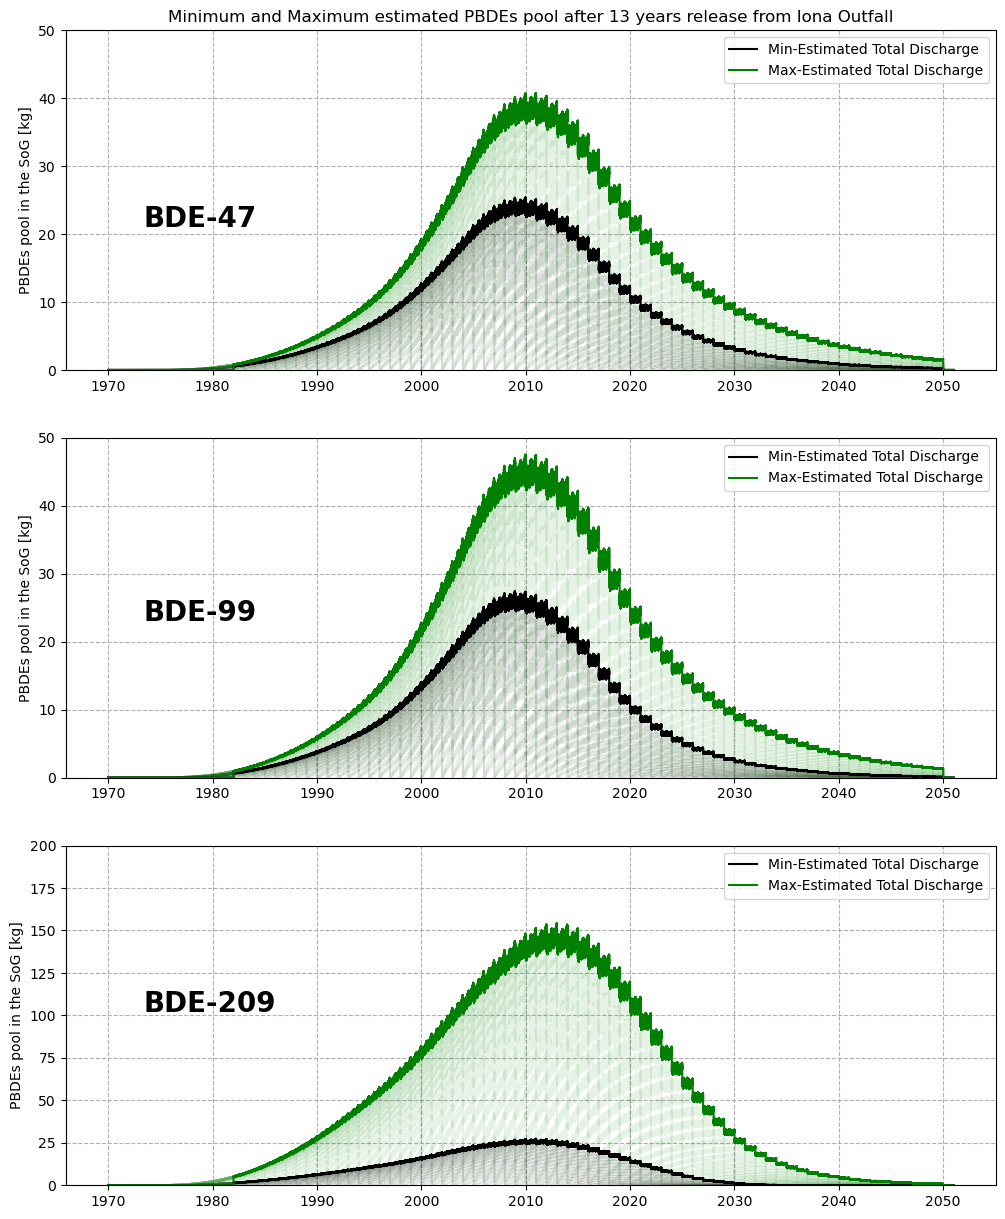

In [100]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_x, min_BDE_47/1000, 'k', alpha = .1)
ax[0].plot(time_x, max_BDE_47/1000, 'g', alpha = .1)
ax[0].plot(time_x, min_BDE_47['Year 12']/1000, 'k', label = 'Min-Estimated Total Discharge')
ax[0].plot(time_x, max_BDE_47['Year 12']/1000, 'g', label = 'Max-Estimated Total Discharge')
ax[0].set_ylim(0,50)
ax[0].text(time_x[10000],int(max_BDE_47['Year 12'].max()/1000/1.9),'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_x, min_BDE_99/1000, 'k', alpha = .1)
ax[1].plot(time_x, max_BDE_99/1000, 'g', alpha = .1)
ax[1].plot(time_x, min_BDE_99['Year 12']/1000, 'k', label = 'Min-Estimated Total Discharge')
ax[1].plot(time_x, max_BDE_99['Year 12']/1000, 'g', label = 'Max-Estimated Total Discharge')
ax[1].set_ylim(0,50)
ax[1].text(time_x[10000],int(max_BDE_99['Year 12'].max()/1000/2),'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_x, min_BDE_209/1000, 'k', alpha = .1)
ax[2].plot(time_x, max_BDE_209/1000, 'g', alpha = .1)
ax[2].plot(time_x, min_BDE_209['Year 12']/1000, 'k', label = 'Min-Estimated Total Discharge')
ax[2].plot(time_x, max_BDE_209['Year 12']/1000, 'g', label = 'Max-Estimated Total Discharge')
ax[2].set_ylim(0,200)
ax[2].text(time_x[10000],int(max_BDE_209['Year 12'].max()/1000/1.5),'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper right')
    axis.set_ylabel('PBDEs pool in the SoG [kg]')

ax[0].set_title('Minimum and Maximum estimated PBDEs pool after 13 years release from Iona Outfall')    

Extrapolation and guidelines

In [101]:
file_year1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
file_year2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'
file_year3 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_3.nc'
file_year4 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_4.nc'
file_year5 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_5.nc'
file_year6 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_6.nc'
file_year7 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_7.nc'
file_year8 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_8.nc'
file_year9 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_9.nc'
file_year10 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_10.nc'
file_year11 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_11.nc'
file_year12 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_12.nc'
file_year13 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_13.nc'
#
year1 = xr.open_dataset(file_year1)
year2 = xr.open_dataset(file_year2)
year3 = xr.open_dataset(file_year3)
year4 = xr.open_dataset(file_year4)
year5 = xr.open_dataset(file_year5)
year6 = xr.open_dataset(file_year6)
year7 = xr.open_dataset(file_year7)
year8 = xr.open_dataset(file_year8)
year9 = xr.open_dataset(file_year9)
year10 = xr.open_dataset(file_year10)
year11 = xr.open_dataset(file_year11)
year12 = xr.open_dataset(file_year12)
year13 = xr.open_dataset(file_year13)

In [102]:
def pad_year(year, conversion, ts_full_yr1):
    ts_full_yeard = (year.status == 2).sum(axis=0) * conversion
    ts_full_year = np.zeros_like(ts_full_yr1)
    ts_full_year[1::2] = ts_full_yeard
    ts_full_year[0] = 0.5 * (ts_full_year[1] + ts_full_year[-1])
    ts_full_year[2::2] = 0.5 * (ts_full_year[1:-2:2] + ts_full_year[3::2])
    return ts_full_year
#
conversion = 1 / 96 # 1 g per day = 96 particles
ts_full_yr1 = (year1.status == 2).sum(axis=0) * conversion
ts_full_yr2 = (year2.status == 2).sum(axis=0) * conversion
ts_full_yr3 = pad_year(year3, conversion, ts_full_yr1)
ts_full_yr4 = pad_year(year4, conversion, ts_full_yr1)
ts_full_yr5 = pad_year(year5, conversion, ts_full_yr1)
ts_full_yr6 = pad_year(year6, conversion, ts_full_yr1)
ts_full_yr7 = pad_year(year7, conversion, ts_full_yr1)
ts_full_yr8 = pad_year(year8, conversion, ts_full_yr1)
ts_full_yr9 = pad_year(year9, conversion, ts_full_yr1)
ts_full_yr10 = pad_year(year10, conversion, ts_full_yr1)
ts_full_yr11 = pad_year(year11, conversion, ts_full_yr1)
ts_full_yr12 = pad_year(year12, conversion, ts_full_yr1)
ts_full_yr13 = pad_year(year13, conversion, ts_full_yr1)

In [103]:
BDE = pd.DataFrame({
'Date': pd.to_datetime(PBDEs_min['Unnamed: 0']),
'Min': PBDEs_min['BDE-99'],
'Max': PBDEs_max['BDE-99']
})
#
BDE['year'] = BDE['Date'].dt.year
discharge_min = BDE.groupby('year')['Min'].mean()
discharge_max = BDE.groupby('year')['Max'].mean()

In [104]:
tseries_concat = np.concatenate([ts_full_yr1, ts_full_yr2, ts_full_yr3, ts_full_yr4, ts_full_yr5,
                                ts_full_yr6, ts_full_yr7, ts_full_yr8, ts_full_yr9, ts_full_yr10,
                                ts_full_yr11, ts_full_yr12, ts_full_yr13])

In [105]:
def curve_double_yr(t, maxv1, maxv2, decay1, decay2, tmm=1):
    # Component 1
    value1 = maxv1 * np.exp(-t/decay1) * (np.exp(np.minimum(t, tmm)/decay1) - 1)
    # Component 2
    value2 = maxv2 * np.exp(-t/decay2) * (np.exp(np.minimum(t, tmm)/decay2) - 1)
    return value1 + value2

In [106]:
fit_double_yr, cov = curve_fit(
    curve_double_yr, 
    np.arange(0, 13, 1/2920), 
    tseries_concat, 
    p0=[20000, 20000, 0.1, 8.0, 1.0],
    bounds=([0, 0, 0.001, 0.001, 0.5], [np.inf, np.inf, np.inf, np.inf, 2.0]), maxfev=10000
)

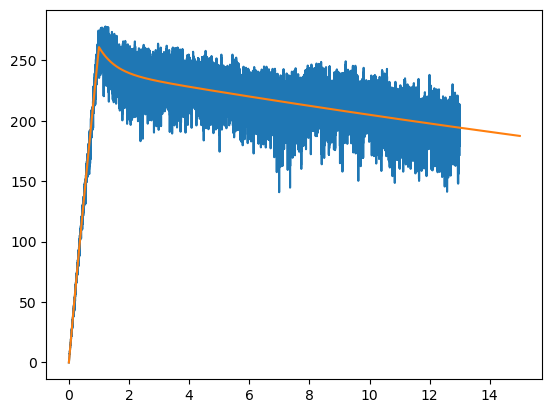

In [107]:
plt.plot(np.arange(0, 13, 1/2920), tseries_concat)
plt.plot(np.arange(0, 15, 1/2920), curve_double_yr(np.arange(0, 15, 1/2920),
                                                   fit_double_yr[0], fit_double_yr[1], fit_double_yr[2], fit_double_yr[3] ))

In [108]:
def extrapolation_total(congener_min, congener_max, BDE_name):
    tseries_concat = np.concatenate([ts_full_yr1, ts_full_yr2, ts_full_yr3, ts_full_yr4, ts_full_yr5,
                                    ts_full_yr6, ts_full_yr7, ts_full_yr8, ts_full_yr9, ts_full_yr10,
                                    ts_full_yr11, ts_full_yr12, ts_full_yr13])
    #
    fit_double_yr, cov = curve_fit(curve_double_yr, np.arange(0, 13, 1/2920), tseries_concat, p0=[20000, 20000, 0.1, 8.0, 1.0],
                                   bounds=([0, 0, 0.001, 0.001, 0.5], [np.inf, np.inf, np.inf, np.inf, 2.0]), maxfev=10000)
    #
    BDE = pd.DataFrame({
    'Date': pd.to_datetime(congener_min['Unnamed: 0']),
    'Min': congener_min[BDE_name],
    'Max': congener_max[BDE_name]
    })
    #
    BDE['year'] = BDE['Date'].dt.year
    discharge_min = BDE.groupby('year')['Min'].mean()
    discharge_max = BDE.groupby('year')['Max'].mean()
    #
    # Min
    pred_min = discharge_min[1970] * curve_double_yr(np.arange(0, max_year-1970, 1/2920), 
                                          fit_double_yr[0], fit_double_yr[1], fit_double_yr[2], fit_double_yr[3],)
    for year in range(1970+1, max_year):
        pred_min[2920*(year-1970):] = (pred_min[2920*(year-1970):] + 
                discharge_min[year] * curve_double_yr(np.arange(0, max_year-year, 1/2920), 
                                                fit_double_yr[0], fit_double_yr[1], fit_double_yr[2], fit_double_yr[3]))
    # Max
    pred_max = discharge_max[1970] * curve_double_yr(np.arange(0, max_year-1970, 1/2920), 
                                          fit_double_yr[0], fit_double_yr[1], fit_double_yr[2], fit_double_yr[3],)
    for year in range(1970+1, max_year):
        pred_max[2920*(year-1970):] = (pred_max[2920*(year-1970):] + 
                discharge_max[year] * curve_double_yr(np.arange(0, max_year-year, 1/2920), 
                                                fit_double_yr[0], fit_double_yr[1], fit_double_yr[2], fit_double_yr[3])) 
    return pred_min, pred_max    

In [109]:
extrapolation_47_min, extrapolation_47_max = extrapolation_total(PBDEs_min, PBDEs_max, BDE_name='BDE-47')
extrapolation_99_min, extrapolation_99_max = extrapolation_total(PBDEs_min, PBDEs_max, BDE_name='BDE-99')
extrapolation_209_min, extrapolation_209_max = extrapolation_total(PBDEs_min, PBDEs_max, BDE_name='BDE-209')

In [110]:
from shapely.geometry import Polygon, Point

path = {'NEMO': '/results2/SalishSea/nowcast-green.202111/',
'coords': '/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc',
'coordsWW3': '/ocean/vvalenzuela/MOAD/grid2/WW3_grid.nc',
'mask': '/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc',
'bat': '/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc',
'out': '/home/vvalenzuela/MOAD/Ocean_Parcels/results/Test_runs',
'home': '/home/vvalenzuela/MOAD/Ocean_Parcels',
'anim': '/home/vvalenzuela/MOAD/Ocean_Parcels/results/PBDE_runs/animations'}
#
coords = xr.open_dataset(path['coords'], decode_times=False)
mask = xr.open_dataset(path['mask'])

In [111]:
colors = [(0, 0, 0, 1),  # Black for land (1)
          (0, 0, 0, 0)]  # Transparent for water (0)
cmap = ListedColormap(colors)

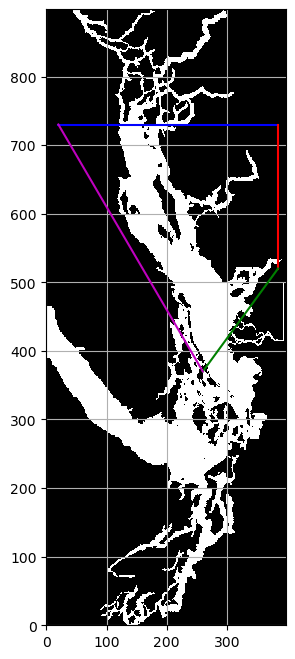

In [112]:
Nx1_1, Ny1_1 = [20,385], [730,730]
Nx1_2, Ny1_2 = [385,385], [730,520]
Nx1_3, Ny1_3 = [385,260], [520,370]
Nx1_4, Ny1_4 = [260,20], [370,730]

#
fig, ax = plt.subplots(figsize = (4,8))
ax.pcolormesh(mask['tmask'][0][0], cmap = cmap)
plt.plot(Nx1_1, Ny1_1, 'b')
plt.plot(Nx1_2, Ny1_2, 'r')
plt.plot(Nx1_3, Ny1_3,'g')
plt.plot(Nx1_4, Ny1_4,'m')
#
ax.set_aspect(1.14)
ax.grid()

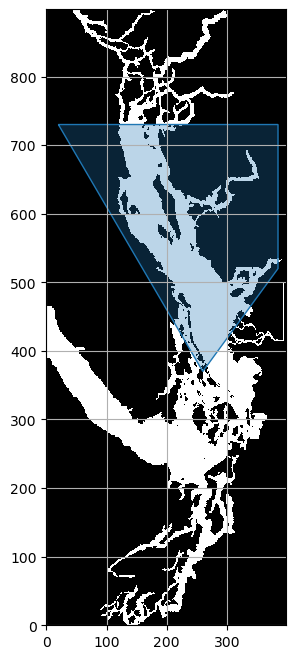

In [113]:
polygon_coords_SoG = [
    (Nx1_1[0], Ny1_1[0]),
    (Nx1_1[1], Ny1_1[1]),
    (Nx1_2[1], Ny1_2[1]),
    (Nx1_3[1], Ny1_3[1]),
    (Nx1_4[1], Ny1_4[1])
]
polygon_SoG = Polygon(polygon_coords_SoG)
#
N1_lon_1, N1_lat_1 = [mask.nav_lon[Ny1_1[0],Nx1_1[0]].values, mask.nav_lon[Ny1_1[1],Nx1_1[1]].values], [mask.nav_lat[Ny1_1[0],Nx1_1[0]].values, mask.nav_lat[Ny1_1[1],Nx1_1[1]].values]
N1_lon_2, N1_lat_2 = [mask.nav_lon[Ny1_2[0],Nx1_2[0]].values, mask.nav_lon[Ny1_2[1],Nx1_2[1]].values], [mask.nav_lat[Ny1_2[0],Nx1_2[0]].values, mask.nav_lat[Ny1_2[1],Nx1_2[1]].values]
N1_lon_3, N1_lat_3 = [mask.nav_lon[Ny1_3[0],Nx1_3[0]].values, mask.nav_lon[Ny1_3[1],Nx1_3[1]].values], [mask.nav_lat[Ny1_3[0],Nx1_3[0]].values, mask.nav_lat[Ny1_3[1],Nx1_3[1]].values]
N1_lon_4, N1_lat_4 = [mask.nav_lon[Ny1_4[0],Nx1_4[0]].values, mask.nav_lon[Ny1_4[1],Nx1_4[1]].values], [mask.nav_lat[Ny1_4[0],Nx1_4[0]].values, mask.nav_lat[Ny1_4[1],Nx1_4[1]].values]

#
polygon_lon_lat_SoG = [
    (N1_lon_1[0], N1_lat_1[0]),
    (N1_lon_1[1], N1_lat_1[1]),
    (N1_lon_2[1], N1_lat_2[1]),
    (N1_lon_3[1], N1_lat_3[1]),
    (N1_lon_4[1], N1_lat_4[1])
]
polygon_coors_SoG = Polygon(polygon_lon_lat_SoG)
#
fig, ax = plt.subplots(figsize = (4,8))
ax.pcolormesh(mask['tmask'][0][0], cmap = cmap)
plot_polygon(polygon_SoG, ax=ax, add_points=False)
#
ax.set_aspect(1.14)
ax.grid()

In [114]:
def volume_region_layer(polygon, min_depth, max_depth):
    # Load
    mesh = xr.open_dataset(path['mask'])
    volume = mesh['volume']
    mask = xr.open_dataset(path['mask'])['tmask'][0]
    #
    depths = mesh['gdept_1d'][0] 
    depth_condition = (depths >= min_depth) & (depths <= max_depth)
    # 
    depth_mask_3d = depth_condition.values[:, np.newaxis, np.newaxis]
    #    
    x = volume['x']  
    y = volume['y'] 
    #
    xx, yy = np.meshgrid(x, y)
    #
    # 2D Mask
    polygon_mask_2d = np.array([
        [polygon.contains(Point(xx[j, i], yy[j, i])) for i in range(len(x))]
        for j in range(len(y))
    ])

    # 3D
    nz = volume.sizes['z']
    polygon_mask_3d = np.repeat(polygon_mask_2d[np.newaxis, :, :], nz, axis=0)

    combined_mask = (polygon_mask_3d & (mask.values == 1) & depth_mask_3d)

    mask_da = xr.DataArray(combined_mask, dims=volume.dims, coords=volume.coords)
    volume_in_polygon_water = volume.where(mask_da).sum().item()
    
    return volume_in_polygon_water

In [115]:
volume_SoG = volume_region_layer(polygon_SoG, min_depth=0, max_depth=450)

In [116]:
time_x_pred = np.arange(1970, max_year, 1/(8*365))

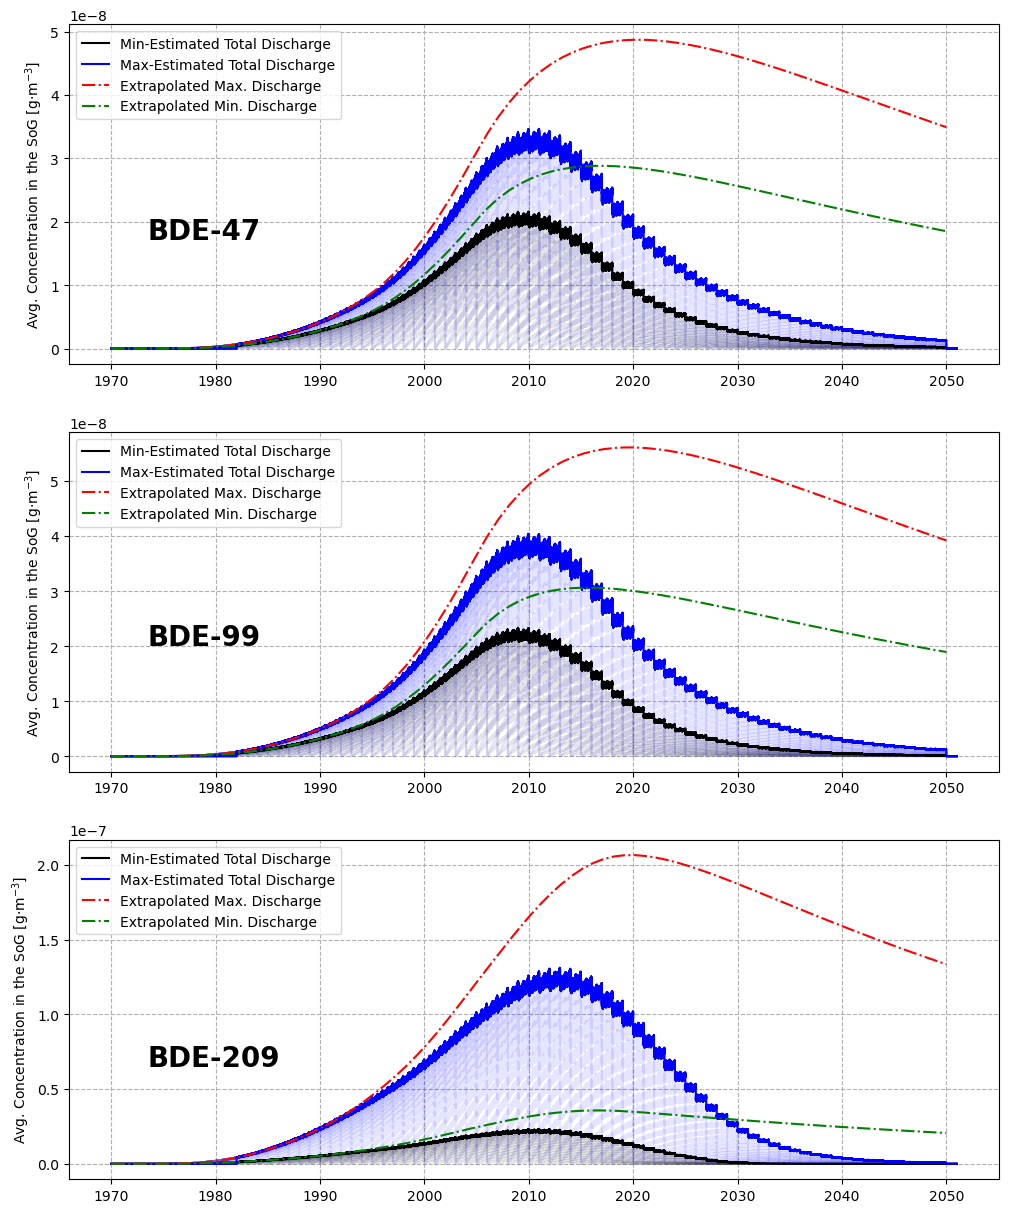

In [117]:
fig, ax = plt.subplots(3,1, figsize = (12, 15))
ax[0].plot(time_x, min_BDE_47/volume_SoG, 'k', alpha = .1)
ax[0].plot(time_x, max_BDE_47/volume_SoG, 'b', alpha = .1)
ax[0].plot(time_x, min_BDE_47['Year 12']/volume_SoG, 'k', label = 'Min-Estimated Total Discharge')
ax[0].plot(time_x, max_BDE_47['Year 12']/volume_SoG, 'b', label = 'Max-Estimated Total Discharge')
#
ax[0].plot(time_x_pred, extrapolation_47_max/volume_SoG, '-.r', label = 'Extrapolated Max. Discharge')
ax[0].plot(time_x_pred, extrapolation_47_min/volume_SoG, '-.g', label = 'Extrapolated Min. Discharge')

#
#ax[0].set_ylim(0,65000/volume_SoG)
ax[0].text(time_x[10000],max_BDE_47['Year 12'].max()/volume_SoG/2,'BDE-47', fontsize = 20, fontweight='bold')

#
ax[1].plot(time_x, min_BDE_99/volume_SoG, 'k', alpha = .1)
ax[1].plot(time_x, max_BDE_99/volume_SoG, 'b', alpha = .1)
ax[1].plot(time_x, min_BDE_99['Year 12']/volume_SoG, 'k', label = 'Min-Estimated Total Discharge')
ax[1].plot(time_x, max_BDE_99['Year 12']/volume_SoG, 'b', label = 'Max-Estimated Total Discharge')
#
ax[1].plot(time_x_pred, extrapolation_99_max/volume_SoG, '-.r', label = 'Extrapolated Max. Discharge')
ax[1].plot(time_x_pred, extrapolation_99_min/volume_SoG, '-.g', label = 'Extrapolated Min. Discharge')
#
#ax[1].set_ylim(0,75000/volume_SoG)
ax[1].text(time_x[10000],max_BDE_99['Year 12'].max()/volume_SoG/2,'BDE-99', fontsize = 20, fontweight='bold')

#
ax[2].plot(time_x, min_BDE_209/volume_SoG, 'k', alpha = .1)
ax[2].plot(time_x, max_BDE_209/volume_SoG, 'b', alpha = .1)
ax[2].plot(time_x, min_BDE_209['Year 12']/volume_SoG, 'k', label = 'Min-Estimated Total Discharge')
ax[2].plot(time_x, max_BDE_209['Year 12']/volume_SoG, 'b', label = 'Max-Estimated Total Discharge')
#
ax[2].plot(time_x_pred, extrapolation_209_max/volume_SoG, '-.r', label = 'Extrapolated Max. Discharge')
ax[2].plot(time_x_pred, extrapolation_209_min/volume_SoG, '-.g', label = 'Extrapolated Min. Discharge')
#
#ax[2].set_ylim(0,300000/volume_SoG)
ax[2].text(time_x[10000],max_BDE_209['Year 12'].max()/volume_SoG/2,'BDE-209', fontsize = 20, fontweight='bold')

#
for axis in ax:
    axis.grid(linestyle = '--')
    axis.legend(loc = 'upper left')
    axis.set_ylabel(r'Avg. Concentration in the SoG [g$\cdot$m$^{-3}$]')

#ax[0].set_title('Minimum and Maximum estimated PBDEs pool after 13 years release from Iona Outfall')    

In [118]:
print('Max BDE-99 converted to ng/L: ', (45000 *1e9) / (volume_SoG*1e3))

Max BDE-99 converted to ng/L:  0.03824929395605146
